In [22]:
import pandas as pd
import numpy as np

In [3]:
features_final = pd.read_csv("../data/extracted_features_mean.csv")

In [4]:
train_groups = ['a', 'b', 'c', 'd']
train_features = features_final[features_final['group_id'].isin(train_groups)]

In [5]:
feature_cols = ["Asymmetry", "Compactness", "Convexity", "Multicolor", "red_pixels", "blue_pixels", "mean_red", "mean_blue", "Entropy", "Hue_Var", "Sat_Var", "Val_Var"]

train_df = train_features[feature_cols + ["Class"]].copy()

In [6]:
train_df["label"] = train_df["Class"].astype(int)
train_df = train_df.drop(columns=["Class"])

In [7]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# 1. Separate features from the target
X = train_df.drop(columns=['label'])
y = train_df['label']

# 2. Split into Training (80%) and Validation (20%)
X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.20, stratify=y, random_state=42
)

# 3. Initialize the Scaler
scaler = StandardScaler()

# 4. Fit and Transform the Training data(calculates the mean and standard deviation of training features.)
X_train_scaled = scaler.fit_transform(X_train)

# 5. Transform the Validation data (We use the training mean/std to scale the validation set)
X_val_scaled = scaler.transform(X_val)


In [11]:
X = train_df.drop(columns=['label'])
y = train_df['label']
scaler = StandardScaler()
train_scale = scaler.fit_transform(X)

In [16]:
from sklearn.model_selection import cross_val_score
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression

# Create a dictionary of the models 
# We use standard settings (defaults) for a fair comparison
models = {
    "KNN": KNeighborsClassifier(),
    "DecisionTree": DecisionTreeClassifier(random_state=42),
    "RandomForest": RandomForestClassifier(random_state=42),
    "LogisticRegression": LogisticRegression()
}

print("--- Model Comparison (Average Accuracy) ---")

# run all the models
for name, model in models.items():
    # cv=5 means the data is split 5 ways; 4 parts train, 1 part tests
    # it repeats this 5 times so every row gets to be the "test" once
    scores = cross_val_score(model, train_scale, y, cv=5)
    print(f"{name}: {scores}")
    #We take the mean (average) of those 5 scores
    print(f"{name}: {scores.mean():.4f}")


--- Model Comparison (Average Accuracy) ---
KNN: [0.49097473 0.49097473 0.55234657 0.46570397 0.5       ]
KNN: 0.5000
DecisionTree: [0.50541516 0.4801444  0.53790614 0.4801444  0.48913043]
DecisionTree: 0.4985
RandomForest: [0.50902527 0.5631769  0.52707581 0.50902527 0.4673913 ]
RandomForest: 0.5151
LogisticRegression: [0.48375451 0.49458484 0.5198556  0.48375451 0.5       ]
LogisticRegression: 0.4964


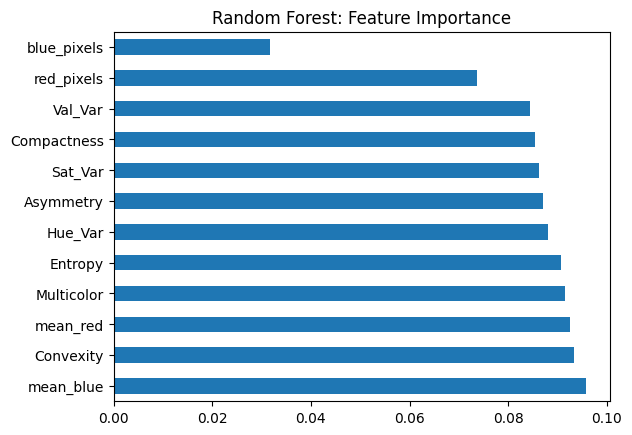

In [14]:
import pandas as pd
import matplotlib.pyplot as plt

# 1. Fit the model
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train_scaled, y_train)

# 2. Get importance and link to column names
importances = pd.Series(rf.feature_importances_, index=X.columns)
importances = importances.sort_values(ascending=False)

# 3. Plot
importances.plot(kind='barh', title='Random Forest: Feature Importance')
plt.show()


In [28]:

n_est_metrics = {"train":[], "val":[]}

print(f"Evaluating n_estimators:")
#Evaluate with different number of trees in the ensemble
n_estimators = [1,5,10,50,100]
for n in n_estimators:
    random_forest = RandomForestClassifier(n_estimators=n,max_depth=1,random_state=42)
    random_forest.fit(X_train_scaled,y_train)

    train_acc = random_forest.score(X_train_scaled,y_train)
    val_acc = random_forest.score(X_val_scaled,y_val)

    n_est_metrics["train"].append(train_acc)
    n_est_metrics["val"].append(val_acc)

    print(f"n_estimators={n} - train_acc: {train_acc} - val_acc: {val_acc}")


#Evaluate with different maximum depth for trees
max_depth_metrics = {"train":[], "val":[]}

print(f"\nEvaluating max_depth:")
depths = [1,3,4,20,None]
for depth in depths:
    random_forest = RandomForestClassifier(n_estimators=100,max_depth=depth,random_state=42) 
    random_forest.fit(X_train_scaled,y_train)

    train_acc = random_forest.score(X_train_scaled,y_train)
    val_acc = random_forest.score(X_val_scaled,y_val)

    max_depth_metrics["train"].append(train_acc)
    max_depth_metrics["val"].append(val_acc)
    
    print(f"max_depth={depth} - train_acc: {train_acc} - val_acc: {val_acc}")


Evaluating n_estimators:
n_estimators=1 - train_acc: 0.5392953929539296 - val_acc: 0.5234657039711191
n_estimators=5 - train_acc: 0.5401987353206865 - val_acc: 0.51985559566787
n_estimators=10 - train_acc: 0.5501355013550135 - val_acc: 0.5090252707581228
n_estimators=50 - train_acc: 0.5465221318879856 - val_acc: 0.5270758122743683
n_estimators=100 - train_acc: 0.5528455284552846 - val_acc: 0.5342960288808665

Evaluating max_depth:
max_depth=1 - train_acc: 0.5528455284552846 - val_acc: 0.5342960288808665
max_depth=3 - train_acc: 0.6314363143631436 - val_acc: 0.4981949458483754
max_depth=4 - train_acc: 0.7028003613369467 - val_acc: 0.5306859205776173
max_depth=20 - train_acc: 1.0 - val_acc: 0.48736462093862815
max_depth=None - train_acc: 1.0 - val_acc: 0.5054151624548736


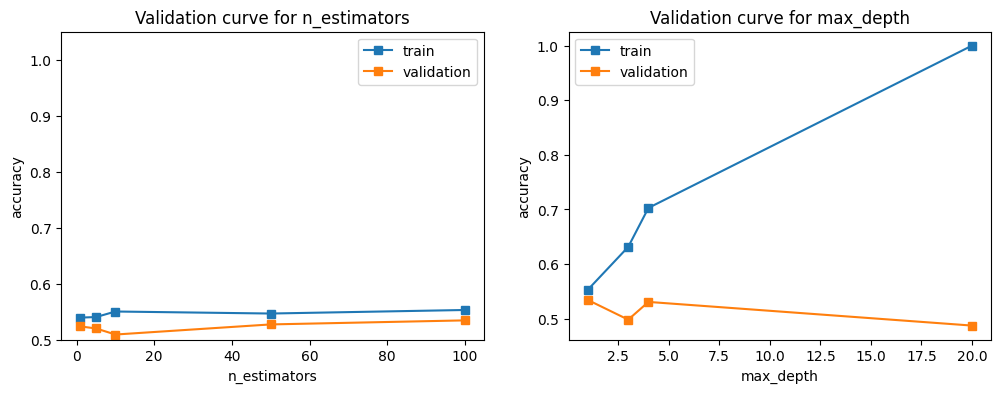

In [29]:
fig, ax = plt.subplots(1, 2, figsize=(12, 4))

ax[0].plot(n_estimators, n_est_metrics["train"], marker='s', label="train")
ax[0].plot(n_estimators, n_est_metrics["val"], marker='s', label="validation")
ax[0].set_ylim(0.5, 1.05)
ax[0].set_xlabel("n_estimators")
ax[0].set_ylabel("accuracy")
ax[0].set_title("Validation curve for n_estimators")
ax[0].legend()

ax[1].plot(depths, max_depth_metrics["train"], marker='s', label="train")
ax[1].plot(depths, max_depth_metrics["val"], marker='s', label="validation")
ax[0].set_ylim(0.5, 1.05)
ax[1].set_xlabel("max_depth")
ax[1].set_ylabel("accuracy")
ax[1].set_title("Validation curve for max_depth")
ax[1].legend()

In [ ]:
def train_RSM(x_train, y_train, n_estimators, number_of_selection):
    """
    params:
        - training_data: All training samples with both X (features) and y (groundtruth)
        - n_estimators: Number of tree in the ensemble
        - number_of_selection: Number of random selection of feature without replacement to create the training dataset
    return:
        - An ensemble of Decision Tree each fitted with randomly selected data from X
    """
    lstModel = []
    
    for _ in range(n_estimators):
        #Create the model to train
        current_model = DecisionTreeClassifier(random_state=42)
        
        #Randomly select the features used by this tree
        selected_features = np.random.choice(x_train.shape[1], size=number_of_selection, replace=False)
        x_subspace = x_train[:, selected_features]

        #Train the model and add to the ensemble, /!\ also keeping the list of features used to also use them during prediction /!\
        current_model.fit(x_subspace,y_train)
        lstModel.append((current_model,selected_features))

    return lstModel

def eval_RSM(lst_classifier, x_val, y_val):
    ensemblePrediction = []
    #For each model in the ensemble, use only the features selected during training for this model and make the prediction
    for model in lst_classifier:
        m = model[0]
        selected_features = model[1]
        x_subspace = x_val[:, selected_features]
        ensemblePrediction.append(m.predict(x_subspace))
    #Transform into numpy array for slicing
    ensemblePrediction = np.array(ensemblePrediction)

    #For each point choose the class with the most vote among the classifiers
    pred = []
    for i in range(len(x_val)):
        preds = ensemblePrediction[:,i]
        pred.append(max(preds,key=list(preds).count))

    #Compare with groundtruth
    nb_good_prediction = sum(pred==y_val)
    print(f"Accuracy of the ensemble: {nb_good_prediction/len(y_val)}")

In [50]:
lst_classifier = train_RSM(X_train_scaled, y_train, 90, 7)
eval_RSM(lst_classifier,X_val_scaled,y_val)

Accuracy of the ensemble: 0.5054151624548736


In [66]:
from sklearn.model_selection import cross_val_score
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler

# 1. DEFINE YOUR COMBINATIONS HERE
# You can add or remove any features inside these lists to test them
feature_packs = {
    "Shape Features": ["Asymmetry", "Convexity", "mean_red", "Entropy"],
    "Color/Texture": ["Multicolor", "Hue_Var", "Entropy"],
    "Top 3 Importance": ["mean_blue", "Convexity", "mean_red"],
    "Hybrid Mix": ["Asymmetry", "Entropy", "mean_red", "mean_blue", "Convexity"],
    "All Features": ["Asymmetry", "Compactness", "Convexity", "Multicolor", "Hue_Var", "Entropy", "mean_red", "mean_blue"]
}

# Use the full development data (Groups A-D)
X_dev = train_df.drop(columns=['label'])
y_dev = train_df['label']

print(f"{'Feature Combo Name':<25} | {'Num Features':<12} | {'Avg Accuracy':<15}")
print("-" * 60)

# 2. RUN THE COMPARISON
for name, cols in feature_packs.items():
    # Select only the chosen columns for this specific test
    X_subset = X_dev[cols]
    
    # Scale only these specific columns
    X_scaled = StandardScaler().fit_transform(X_subset)
    
    # Run Random Forest with Cross-Validation
    # (Using n_estimators=100 and max_depth=5 as safe defaults)
    rf = RandomForestClassifier(n_estimators=85, max_depth=5, random_state=42)
    scores = cross_val_score(rf, X_scaled, y_dev, cv=5)
    
    print(f"{name:<25} | {len(cols):<12} | {scores.mean():.4f}")


Feature Combo Name        | Num Features | Avg Accuracy   
------------------------------------------------------------
Shape Features            | 4            | 0.5043
Color/Texture             | 3            | 0.4957
Top 3 Importance          | 3            | 0.5296
Hybrid Mix                | 5            | 0.5339
All Features              | 8            | 0.5188


In [83]:
# 1. Define your different feature combinations
feature_packs = {
    "Shape_Only": ["Asymmetry", "Convexity", "Entropy"],
    "Color_Texture": ["Multicolor", "Hue_Var", "Entropy"],
    "Top_3_Importance": ["mean_blue", "Convexity", "mean_red"],
    "Hybrid Mix": ["Asymmetry", "Entropy", "mean_red", "mean_blue", "Convexity"]
}

# 2. Loop through each combination to find the best one
for pack_name, cols in feature_packs.items():
    print(f"\n--- Testing Combination: {pack_name} ---")
    
    # Prepare and Scale data for this specific combination
    X_train_sub = X_train[cols]
    X_val_sub = X_val[cols]
    
    scaler = StandardScaler()
    X_train_scaled_sub = scaler.fit_transform(X_train_sub)
    X_val_scaled_sub = scaler.transform(X_val_sub)
    
    n_est_metrics = {"train":[], "val":[]}
    print(f"Evaluating n_estimators:")
    n_estimators = [1, 5, 10, 50, 100]
    for n in n_estimators:
        # We use max_depth=3 as a stable baseline for testing n_estimators
        random_forest = RandomForestClassifier(n_estimators=n, max_depth=3, random_state=42)
        random_forest.fit(X_train_scaled_sub, y_train)

        train_acc = random_forest.score(X_train_scaled_sub, y_train)
        val_acc = random_forest.score(X_val_scaled_sub, y_val)

        n_est_metrics["train"].append(train_acc)
        n_est_metrics["val"].append(val_acc)
        print(f"n_estimators={n:3} - train_acc: {train_acc:.3f} - val_acc: {val_acc:.3f}")

    max_depth_metrics = {"train":[], "val":[]}
    print(f"Evaluating max_depth:")
    depths = [1, 3, 5, 10, None]
    for depth in depths:
        # We use the best n_estimators (usually 100) to test depth
        random_forest = RandomForestClassifier(n_estimators=100, max_depth=depth, random_state=42) 
        random_forest.fit(X_train_scaled_sub, y_train)

        train_acc = random_forest.score(X_train_scaled_sub, y_train)
        val_acc = random_forest.score(X_val_scaled_sub, y_val)

        max_depth_metrics["train"].append(train_acc)
        max_depth_metrics["val"].append(val_acc)
        print(f"max_depth={str(depth):4} - train_acc: {train_acc:.3f} - val_acc: {val_acc:.3f}")



--- Testing Combination: Shape_Only ---
Evaluating n_estimators:
n_estimators=  1 - train_acc: 0.527 - val_acc: 0.523
n_estimators=  5 - train_acc: 0.550 - val_acc: 0.520
n_estimators= 10 - train_acc: 0.570 - val_acc: 0.523
n_estimators= 50 - train_acc: 0.604 - val_acc: 0.516
n_estimators=100 - train_acc: 0.614 - val_acc: 0.545
Evaluating max_depth:
max_depth=1    - train_acc: 0.534 - val_acc: 0.552
max_depth=3    - train_acc: 0.614 - val_acc: 0.545
max_depth=5    - train_acc: 0.743 - val_acc: 0.552
max_depth=10   - train_acc: 0.948 - val_acc: 0.542
max_depth=None - train_acc: 1.000 - val_acc: 0.531

--- Testing Combination: Color_Texture ---
Evaluating n_estimators:
n_estimators=  1 - train_acc: 0.531 - val_acc: 0.523
n_estimators=  5 - train_acc: 0.573 - val_acc: 0.505
n_estimators= 10 - train_acc: 0.576 - val_acc: 0.505
n_estimators= 50 - train_acc: 0.582 - val_acc: 0.516
n_estimators=100 - train_acc: 0.579 - val_acc: 0.527
Evaluating max_depth:
max_depth=1    - train_acc: 0.538 - 

Final Model AUC: 0.5429


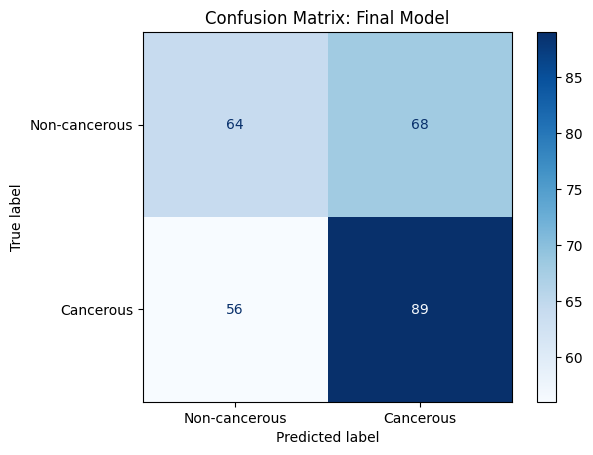

In [95]:
from sklearn.metrics import roc_auc_score, confusion_matrix, ConfusionMatrixDisplay

# 1. SET YOUR BEST SETTINGS HERE
# Replace with the best combination and numbers you found
best_cols = ["Entropy", "mean_red", "mean_blue", "Convexity"] # Example
best_n = 100 
best_depth = 7

# 2. Prepare the data with your winning features
X_train_final = X_train[best_cols]
X_val_final = X_val[best_cols]

scaler = StandardScaler()
X_train_final_scaled = scaler.fit_transform(X_train_final)
X_val_final_scaled = scaler.transform(X_val_final)

# 3. Train the Final Model
final_model = RandomForestClassifier(n_estimators=best_n, max_depth=best_depth, random_state=42)
final_model.fit(X_train_final_scaled, y_train)

# 4. Get PROBABILITIES and AUC
# [:, 1] gets the probability of the image being a Lesion (Class 1)
probs = final_model.predict_proba(X_val_final_scaled)[:, 1]
auc_score = roc_auc_score(y_val, probs)

# 5. Get PREDICTIONS (0 or 1) and Confusion Matrix
#predictions = final_model.predict(X_val_final_scaled)
#cm = confusion_matrix(y_val, predictions)

pos_class_probs = final_model.predict_proba(X_val_final_scaled)[:, 1]
 
# 2. Define your threshold (e.g., 0.3)
threshold = 0.505
 
# 3. Create new class predictions based on the custom threshold
# If prob >= threshold, classify as 1, else 0
custom_predictions = (pos_class_probs >= threshold).astype(int)
 
# 4. Now generate the confusion matrix with your custom labels
from sklearn.metrics import confusion_matrix
cm_custom = confusion_matrix(y_val, custom_predictions)

# --- DISPLAY RESULTS ---
print(f"Final Model AUC: {auc_score:.4f}")

# Plot the Confusion Matrix
disp = ConfusionMatrixDisplay(confusion_matrix=cm_custom, display_labels=["Non-cancerous", "Cancerous"])
disp.plot(cmap="Blues")
plt.title("Confusion Matrix: Final Model")
plt.show()


Validation ROC AUC Score: 0.5346


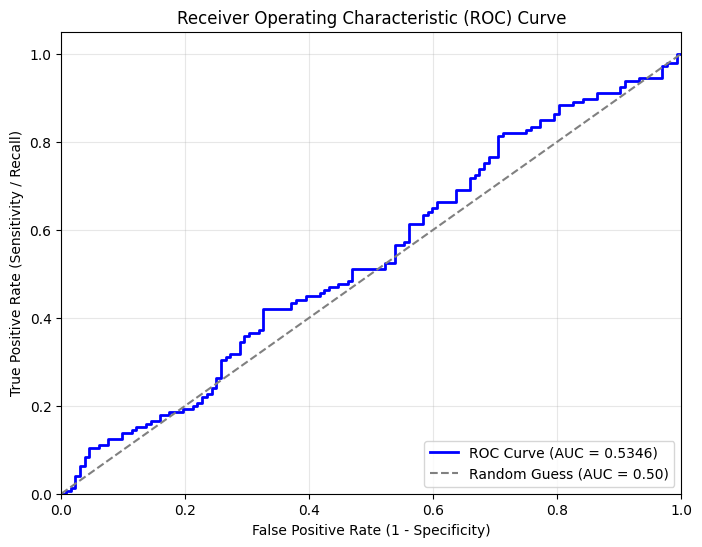

In [92]:
import matplotlib.pyplot as plt

from sklearn.metrics import roc_curve, roc_auc_score

# 1. Get the predicted probabilities for the positive class (Class 1, "Cancerous")

# final_model is your trained RandomForest, X_val_scaled is your scaled validation features

y_val_probs = final_model.predict_proba(X_val_final_scaled)[:, 1]

# 2. Calculate False Positive Rate, True Positive Rate, and Thresholds

fpr, tpr, thresholds = roc_curve(y_val, y_val_probs)

# 3. Calculate the overall AUC Score

auc_score = roc_auc_score(y_val, y_val_probs)

print(f"Validation ROC AUC Score: {auc_score:.4f}")

# 4. Plot the ROC Curve

plt.figure(figsize=(8, 6))

plt.plot(fpr, tpr, color='blue', lw=2, label=f'ROC Curve (AUC = {auc_score:.4f})')

plt.plot([0, 1], [0, 1], color='gray', linestyle='--', label='Random Guess (AUC = 0.50)')

plt.xlim([0.0, 1.0])

plt.ylim([0.0, 1.05])

plt.xlabel('False Positive Rate (1 - Specificity)')

plt.ylabel('True Positive Rate (Sensitivity / Recall)')

plt.title('Receiver Operating Characteristic (ROC) Curve')

plt.legend(loc="lower right")

plt.grid(True, alpha=0.3)

plt.show()
 